<a href="https://colab.research.google.com/github/slendrac123/I.A.-y-Mini-Robots/blob/main/6.Machine_Learning/Actividad5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Actividad 5 – Algoritmo de Bayes Ingenuo (Naive Bayes)

**Algoritmo:** Naive Bayes — GaussianNB · MultinomialNB  
**Datasets:** Iris (numérico) · SPAM sintético (texto) · Breast Cancer  


---

## 1. Fundamento teórico: Teorema de Bayes

El algoritmo Naive Bayes se basa en el **Teorema de Bayes**:

$$P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}$$

| Término | Nombre | Descripción |
|---|---|---|
| $P(C \mid X)$ | **Posterior** | Probabilidad de la clase C dados los atributos X |
| $P(X \mid C)$ | **Verosimilitud** | Probabilidad de observar X si la clase es C |
| $P(C)$ | **Prior** | Probabilidad a priori de la clase C |
| $P(X)$ | **Evidencia** | Constante para todas las clases |

### El supuesto 'Naive'
Asume independencia condicional entre atributos:
$$P(X \mid C) = \prod_{i=1}^{n} P(x_i \mid C) \qquad \Rightarrow \qquad \hat{C} = \underset{C}{\arg\max} \; P(C) \cdot \prod_{i=1}^{n} P(x_i \mid C)$$

### Variantes del algoritmo
| Variante | Cuándo usarla | Distribución asumida |
|---|---|---|
| **GaussianNB** | Atributos numéricos continuos | Normal (Gaussiana) |
| **MultinomialNB** | Conteo de palabras (texto) | Multinomial |
| **BernoulliNB** | Atributos binarios | Bernoulli |

**Ventajas:** muy rápido, funciona con pocos datos, ideal para texto, maneja alta dimensionalidad.  
**Desventajas:** el supuesto de independencia rara vez se cumple; no captura correlaciones.


In [ ]:
# ORDEN: 1.1 - Importación de Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from scipy.stats import norm

print('Librerías importadas ✓')


Librerías importadas ✓


---
## 2. Cálculo manual – Conexión directa con el filtro SPAM


Se describe el filtro SPAM como ejemplo central de ML.  
Calculamos la probabilidad de que un correo sea SPAM si contiene la palabra **"gratis"**.


In [ ]:
# ORDEN: 1.3 - Cálculo Manual – Filtro SPAM (Código)
print('=' * 60)
print('  EJEMPLO MANUAL: Filtro SPAM – Teorema de Bayes')
print('=' * 60)

total_spam = 40; total_ham = 60; total = 100
spam_gratis = 30; ham_gratis = 5

P_spam = total_spam / total
P_ham  = total_ham  / total
P_gratis_spam = spam_gratis / total_spam
P_gratis_ham  = ham_gratis  / total_ham
P_gratis = (spam_gratis + ham_gratis) / total

P_spam_dado_gratis = (P_gratis_spam * P_spam) / P_gratis
P_ham_dado_gratis  = (P_gratis_ham  * P_ham)  / P_gratis

print(f'\nPrior:          P(spam)={P_spam:.2f}  |  P(ham)={P_ham:.2f}')
print(f'Verosimilitud:  P(gratis|spam)={P_gratis_spam:.2f}  |  P(gratis|ham)={P_gratis_ham:.4f}')
print(f'Evidencia:      P(gratis)={P_gratis:.2f}')
print(f'\nPosterior:')
print(f'  P(spam|gratis) = {P_spam_dado_gratis:.4f} ({P_spam_dado_gratis*100:.1f}%)')
print(f'  P(ham|gratis)  = {P_ham_dado_gratis:.4f} ({P_ham_dado_gratis*100:.1f}%)')
pred = 'SPAM' if P_spam_dado_gratis > P_ham_dado_gratis else 'HAM'
print(f'\n→ DECISIÓN: El correo con "gratis" es clasificado como → {pred}')

# Extensión: dos palabras (supuesto Naive)
print('\n' + '─'*60)
print('Extensión: correo con "gratis" Y "regalo" (supuesto Naive)')
spam_regalo = 25; ham_regalo = 3
P_regalo_spam = spam_regalo / total_spam
P_regalo_ham  = ham_regalo  / total_ham
score_spam = P_spam * P_gratis_spam * P_regalo_spam
score_ham  = P_ham  * P_gratis_ham  * P_regalo_ham
total_sc = score_spam + score_ham
print(f'  Score spam = {score_spam:.6f}  |  Score ham = {score_ham:.6f}')
print(f'  P(spam|gratis,regalo) = {score_spam/total_sc:.4f} ({score_spam/total_sc*100:.1f}%)')


  EJEMPLO MANUAL: Filtro SPAM – Teorema de Bayes

Prior:          P(spam)=0.40  |  P(ham)=0.60
Verosimilitud:  P(gratis|spam)=0.75  |  P(gratis|ham)=0.0833
Evidencia:      P(gratis)=0.35

Posterior:
  P(spam|gratis) = 0.8571 (85.7%)
  P(ham|gratis)  = 0.1429 (14.3%)

→ DECISIÓN: El correo con "gratis" es clasificado como → SPAM

────────────────────────────────────────────────────────────
Extensión: correo con "gratis" Y "regalo" (supuesto Naive)
  Score spam = 0.187500  |  Score ham = 0.002500
  P(spam|gratis,regalo) = 0.9868 (98.7%)


---
## 9. MultinomialNB con Dataset Real de SPAM (SMS Spam Collection)

Vamos a utilizar el popular dataset 'SMS Spam Collection' para una clasificación de texto más realista. Este dataset contiene mensajes SMS etiquetados como 'ham' o 'spam'.


In [ ]:
import urllib.request

# URL del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_path = "smsspamcollection.zip"

# Descargar el archivo zip
urllib.request.urlretrieve(url, zip_path)

# Descomprimir el archivo (contiene un solo archivo 'SMSSpamCollection')
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./')

# Cargar el dataset usando pandas
sms_df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'message'])

# Convertir las etiquetas a numéricas (spam=1, ham=0)
sms_df['label'] = sms_df['label'].map({'ham': 0, 'spam': 1})

display(sms_df.head())
print(f"Total de mensajes: {len(sms_df)}")
print(f"Mensajes SPAM: {sms_df['label'].sum()}")
print(f"Mensajes HAM: {len(sms_df) - sms_df['label'].sum()}")


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Total de mensajes: 5572
Mensajes SPAM: 747
Mensajes HAM: 4825


In [ ]:
# Dividir el dataset en conjuntos de entrenamiento y prueba
X_sms = sms_df['message']
y_sms = sms_df['label']

X_tr_sms, X_te_sms, y_tr_sms, y_te_sms = train_test_split(
    X_sms, y_sms, test_size=0.30, random_state=42, stratify=y_sms
)

print(f"Mensajes de entrenamiento: {len(X_tr_sms)}")
print(f"Mensajes de prueba: {len(X_te_sms)}")


Mensajes de entrenamiento: 3900
Mensajes de prueba: 1672


Precisión del filtro SMS SPAM: 0.9486 (94.9%)

Reporte de clasificación:
              precision    recall  f1-score   support

         HAM      0.944     1.000     0.971      1448
        SPAM      1.000     0.616     0.762       224

    accuracy                          0.949      1672
   macro avg      0.972     0.808     0.867      1672
weighted avg      0.951     0.949     0.943      1672



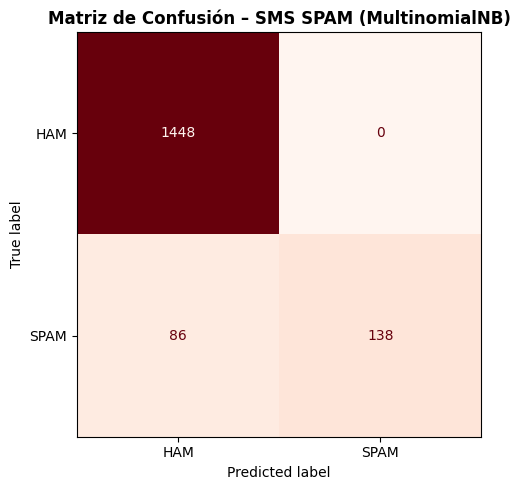

In [ ]:
# Pipeline: TF-IDF + MultinomialNB para SMS
pipe_sms = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)),
    ('nb', MultinomialNB(alpha=1.0)) # Se puede ajustar alpha con validación cruzada
])

pipe_sms.fit(X_tr_sms, y_tr_sms)
y_pred_sms = pipe_sms.predict(X_te_sms)
acc_sms = accuracy_score(y_te_sms, y_pred_sms)

print(f'Precisión del filtro SMS SPAM: {acc_sms:.4f} ({acc_sms*100:.1f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_te_sms, y_pred_sms, target_names=['HAM','SPAM'], digits=3))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_te_sms, y_pred_sms),
    display_labels=['HAM', 'SPAM']
).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de Confusión – SMS SPAM (MultinomialNB)', fontweight='bold')
plt.tight_layout(); plt.show()


SMS Spam Collection: Palabras más informativas

Analizamos las palabras que el modelo `MultinomialNB` considera más relevantes para clasificar mensajes como SPAM o HAM en el dataset SMS Spam Collection.

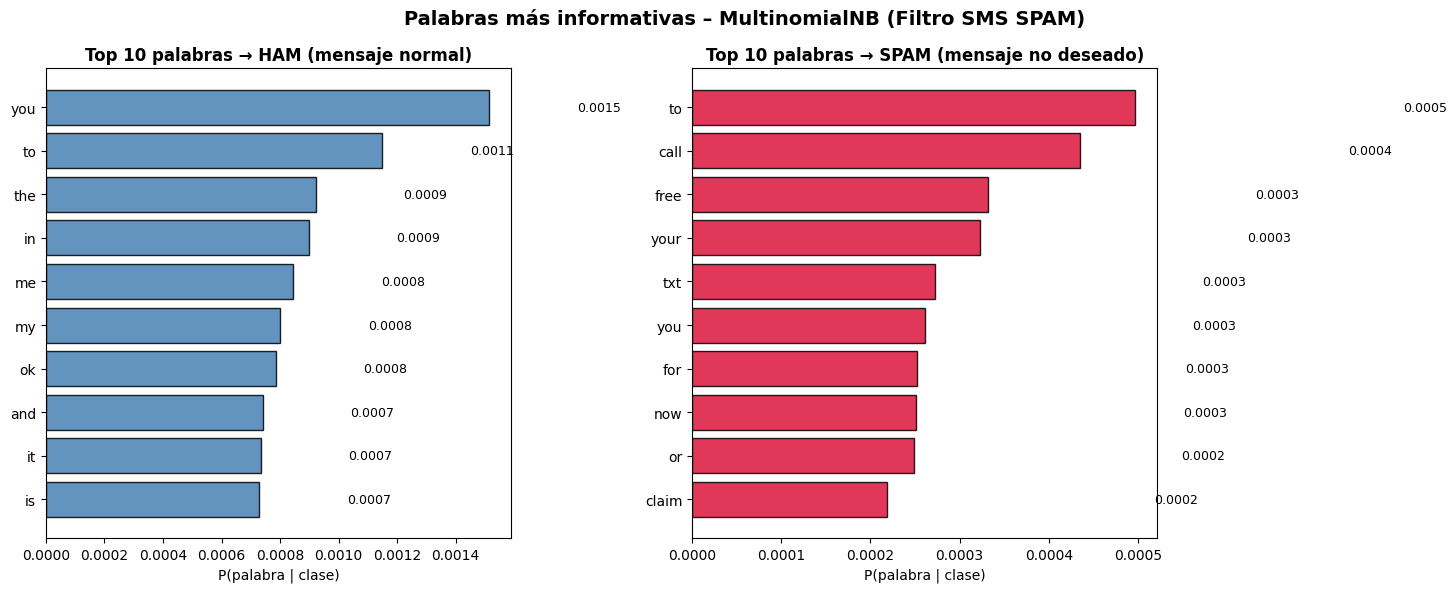

In [ ]:
vocabulario_sms = pipe_sms.named_steps['tfidf'].get_feature_names_out()
log_probs_sms   = pipe_sms.named_steps['nb'].feature_log_prob_
n_top = 10

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, clase, color, titulo in zip(
    axes, [0, 1], ['steelblue', 'crimson'],
    ['Top 10 palabras → HAM (mensaje normal)', 'Top 10 palabras → SPAM (mensaje no deseado)']
):
    # Sort features by log probability for the current class
    idx = np.argsort(log_probs_sms[clase])[-n_top:][::-1]
    palabras = [vocabulario_sms[i] for i in idx]
    valores  = np.exp(log_probs_sms[clase][idx])
    bars = ax.barh(palabras[::-1], valores[::-1], color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, valores[::-1]):
        ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('P(palabra | clase)')
    ax.set_title(titulo, fontweight='bold')

plt.suptitle('Palabras más informativas – MultinomialNB (Filtro SMS SPAM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



---
## 4. GaussianNB: Clasificación numérica – Dataset Iris

`GaussianNB` estima la **media (μ)** y **varianza (σ²)** de cada atributo por clase  
y usa la función de densidad gaussiana como verosimilitud.


In [ ]:
# ORDEN: 3.1 - GaussianNB: Iris (Entrenamiento y Evaluación)
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target)

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.30, random_state=42, stratify=y_iris
)

gnb = GaussianNB()
gnb.fit(X_tr_i, y_tr_i)
y_pred_iris = gnb.predict(X_te_i)
acc_iris = accuracy_score(y_te_i, y_pred_iris)

print(f'Precisión GaussianNB (Iris): {acc_iris:.4f} ({acc_iris*100:.1f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_te_i, y_pred_iris, target_names=iris.target_names, digits=3))

print('\nMedias (μ) aprendidas por clase:')
display(pd.DataFrame(gnb.theta_, index=iris.target_names, columns=iris.feature_names).round(3))


Precisión GaussianNB (Iris): 0.9111 (91.1%)

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        15
  versicolor      0.824     0.933     0.875        15
   virginica      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45


Medias (μ) aprendidas por clase:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.989,3.426,1.486,0.240
versicolor,5.949,2.731,4.237,1.309
virginica,6.683,3.009,5.631,2.069


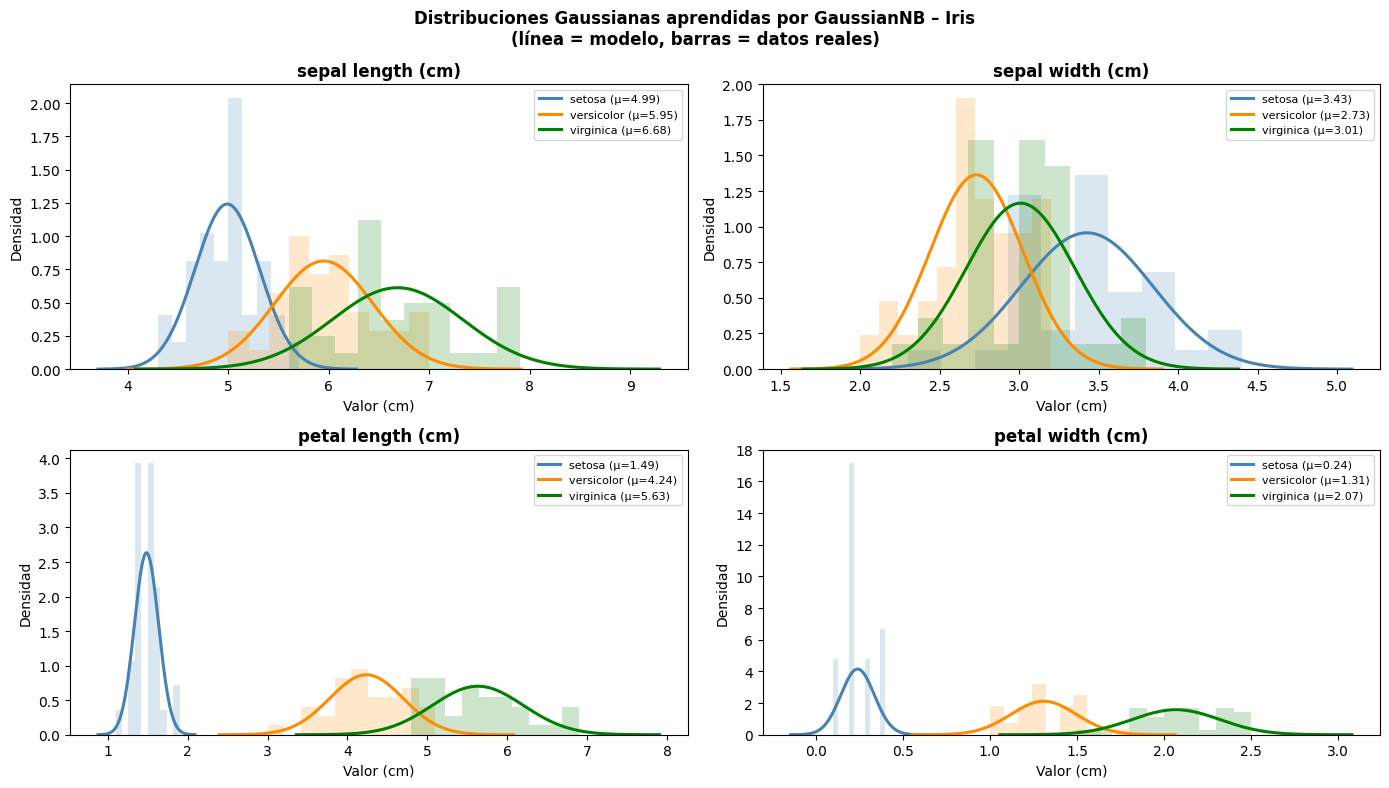

In [ ]:
# Distribuciones gaussianas aprendidas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
colores = ['steelblue', 'darkorange', 'green']

for i, feature in enumerate(iris.feature_names):
    ax = axes[i]
    for clase in range(3):
        mu    = gnb.theta_[clase, i]
        sigma = np.sqrt(gnb.var_[clase, i])
        xr    = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
        ax.plot(xr, norm.pdf(xr, mu, sigma),
                label=f'{iris.target_names[clase]} (μ={mu:.2f})',
                color=colores[clase], linewidth=2.2)
        ax.hist(X_tr_i.loc[y_tr_i == clase, feature], bins=10,
                alpha=0.2, color=colores[clase], density=True)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Valor (cm)'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones Gaussianas aprendidas por GaussianNB – Iris\n'
             '(línea = modelo, barras = datos reales)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


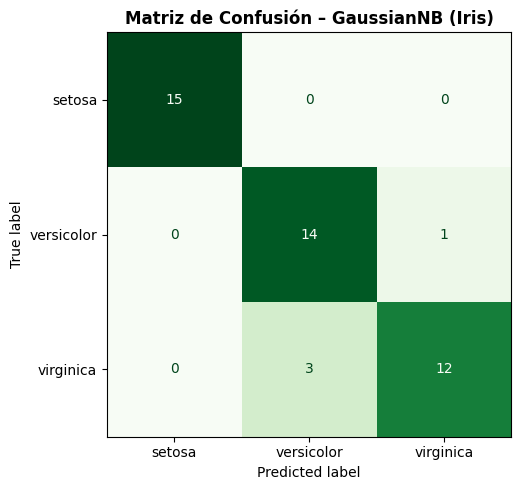

Validación cruzada 5-fold: 0.9533 ± 0.0267


In [ ]:
# Matriz de confusión + validación cruzada
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_te_i, y_pred_iris),
    display_labels=iris.target_names
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión – GaussianNB (Iris)', fontweight='bold')
plt.tight_layout(); plt.show()

scores_iris = cross_val_score(GaussianNB(), X_iris, y_iris, cv=5)
print(f'Validación cruzada 5-fold: {scores_iris.mean():.4f} ± {scores_iris.std():.4f}')




---
## 5. GaussianNB con Dataset de Vinos (Wine Dataset)

Para el `GaussianNB`, usaremos el `Wine Dataset`, que es un clásico conjunto de datos numérico para clasificación de tipos de vino.


In [ ]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

display(X_wine.head())
print(f"Total de muestras: {len(X_wine)}")
print(f"Clases de vino: {wine.target_names}")


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Total de muestras: 178
Clases de vino: ['class_0' 'class_1' 'class_2']


In [ ]:

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_wine, y_wine, test_size=0.30, random_state=42, stratify=y_wine
)

print(f"Muestras de entrenamiento: {len(X_tr_w)}")
print(f"Muestras de prueba: {len(X_te_w)}")


Muestras de entrenamiento: 124
Muestras de prueba: 54


Precisión GaussianNB (Wine): 1.0000 (100.0%)

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        18
     class_1      1.000     1.000     1.000        21
     class_2      1.000     1.000     1.000        15

    accuracy                          1.000        54
   macro avg      1.000     1.000     1.000        54
weighted avg      1.000     1.000     1.000        54



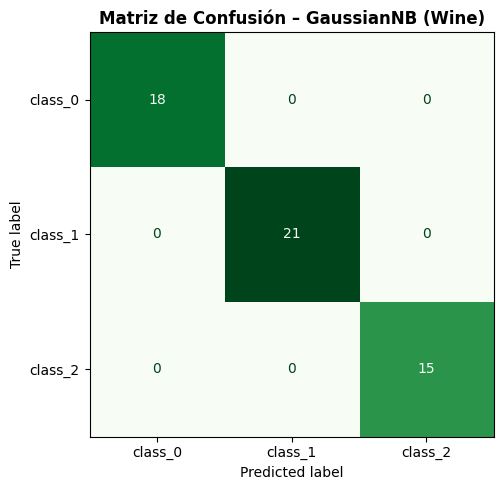

Validación cruzada 5-fold: 0.9663 ± 0.0211


In [ ]:

# Entrenar y evaluar GaussianNB en el Wine Dataset
gnb_w = GaussianNB()
gnb_w.fit(X_tr_w, y_tr_w)
y_pred_w = gnb_w.predict(X_te_w)
acc_w = accuracy_score(y_te_w, y_pred_w)

print(f'Precisión GaussianNB (Wine): {acc_w:.4f} ({acc_w*100:.1f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_te_w, y_pred_w, target_names=wine.target_names, digits=3))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_te_w, y_pred_w),
    display_labels=wine.target_names
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión – GaussianNB (Wine)', fontweight='bold')
plt.tight_layout(); plt.show()

# Validación cruzada
scores_w = cross_val_score(GaussianNB(), X_wine, y_wine, cv=5)
print(f'Validación cruzada 5-fold: {scores_w.mean():.4f} ± {scores_w.std():.4f}')



## 6. GaussianNB en diagnóstico médico – Breast Cancer Wisconsin

El **diagnóstico médico** es una de las aplicaciones más importantes de ML.  
Clasificamos tumores de mama como **benignos o malignos** usando 30 atributos extraídos de biopsias.


In [ ]:
cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = pd.Series(cancer.target)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_c, y_c, test_size=0.30, random_state=42, stratify=y_c
)

gnb_c = GaussianNB()
gnb_c.fit(X_tr_c, y_tr_c)
y_pred_c = gnb_c.predict(X_te_c)
acc_c = accuracy_score(y_te_c, y_pred_c)

print(f'Dataset Breast Cancer: {X_c.shape[0]} muestras, {X_c.shape[1]} atributos')
print(f'Clases: {cancer.target_names}  (malignos={sum(y_c==0)}, benignos={sum(y_c==1)})')
print(f'\nPrecisión en diagnóstico tumoral: {acc_c:.4f} ({acc_c*100:.1f}%)')
print('\nReporte de clasificación:')
print(classification_report(y_te_c, y_pred_c, target_names=cancer.target_names, digits=3))

print('\nNota crítica:')
print('  En diagnóstico médico, el RECALL sobre "malignant" es prioritario.')
print('  Un FN (maligno clasificado como benigno) puede tener consecuencias fatales.')


Dataset Breast Cancer: 569 muestras, 30 atributos
Clases: ['malignant' 'benign']  (malignos=212, benignos=357)

Precisión en diagnóstico tumoral: 0.9474 (94.7%)

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant      0.966     0.891     0.927        64
      benign      0.938     0.981     0.959       107

    accuracy                          0.947       171
   macro avg      0.952     0.936     0.943       171
weighted avg      0.948     0.947     0.947       171


Nota crítica:
  En diagnóstico médico, el RECALL sobre "malignant" es prioritario.
  Un FN (maligno clasificado como benigno) puede tener consecuencias fatales.


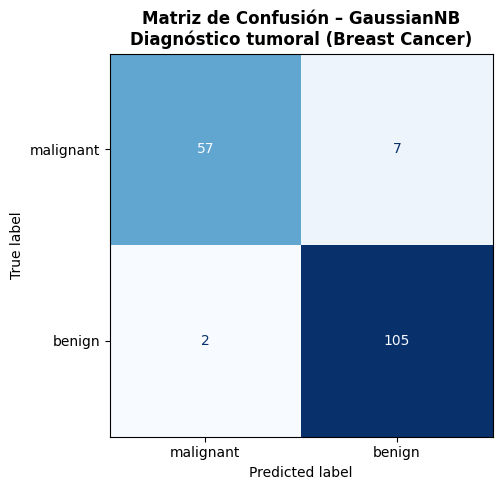

Validación cruzada 5-fold: 0.9385 ± 0.0146


In [ ]:

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_te_c, y_pred_c),
    display_labels=cancer.target_names
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión – GaussianNB\nDiagnóstico tumoral (Breast Cancer)', fontweight='bold')
plt.tight_layout(); plt.show()

scores_c = cross_val_score(GaussianNB(), X_c, y_c, cv=5)
print(f'Validación cruzada 5-fold: {scores_c.mean():.4f} ± {scores_c.std():.4f}')


Suavizado de Laplace (Introducción)
---
## 6. Suavizado de Laplace (hiperparámetro alpha)

Si una palabra no aparece en el entrenamiento de una clase, su probabilidad es 0 y anula el producto total.  
El suavizado de Laplace resuelve esto añadiendo `alpha` a cada conteo:
$$P(x_i \mid C) = \frac{\text{conteo}(x_i, C) + \alpha}{\text{conteo}(C) + \alpha \cdot |V|}$$


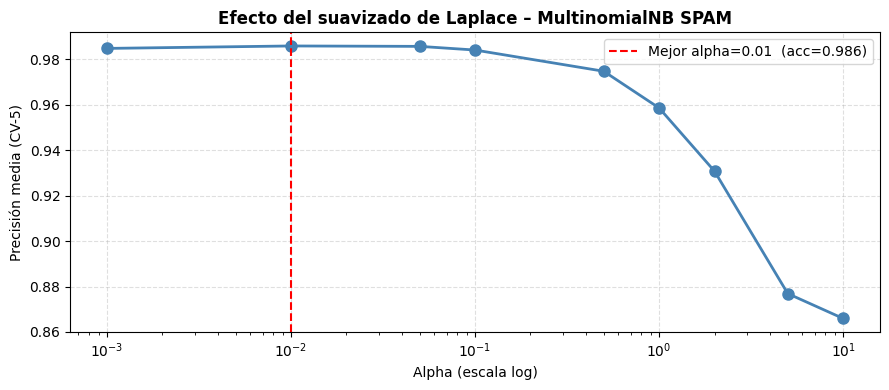

Alpha óptimo: 0.01  →  Precisión CV: 0.9858


In [ ]:

alphas   = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
scores_a = []

for a in alphas:
    pipe_a = Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('nb', MultinomialNB(alpha=a))
    ])
    sc = cross_val_score(pipe_a, X_sms, y_sms, cv=5, scoring='accuracy')
    scores_a.append(sc.mean())

mejor_idx = int(np.argmax(scores_a))
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, scores_a, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=alphas[mejor_idx], color='red', linestyle='--',
           label=f'Mejor alpha={alphas[mejor_idx]}  (acc={max(scores_a):.3f})')
ax.set_xlabel('Alpha (escala log)'); ax.set_ylabel('Precisión media (CV-5)')
ax.set_title('Efecto del suavizado de Laplace – MultinomialNB SPAM', fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f'Alpha óptimo: {alphas[mejor_idx]}  →  Precisión CV: {max(scores_a):.4f}')



---
## 7. Comparación: Naive Bayes vs. otros algoritmos


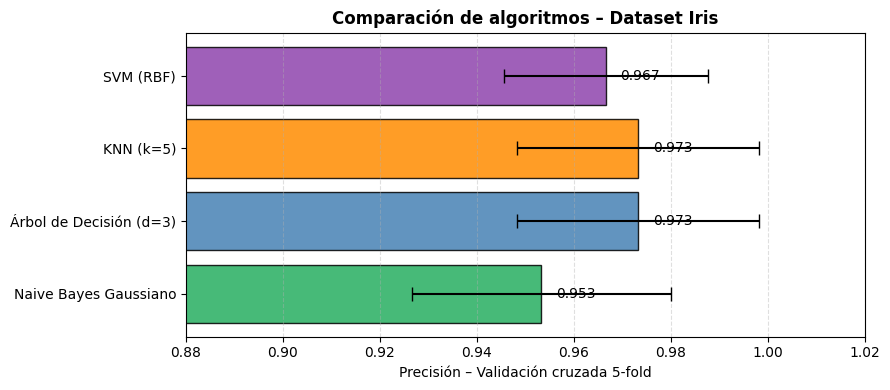

Resultados:
  Naive Bayes Gaussiano          0.9533 ± 0.0267
  Árbol de Decisión (d=3)        0.9733 ± 0.0249
  KNN (k=5)                      0.9733 ± 0.0249
  SVM (RBF)                      0.9667 ± 0.0211


In [ ]:
# ORDEN: 7.1 - Comparación con Otros Algoritmos (Código y Resultados)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

modelos = {
    'Naive Bayes Gaussiano' : GaussianNB(),
    'Árbol de Decisión (d=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'KNN (k=5)'              : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'              : SVC(kernel='rbf', random_state=42),
}

resultados = {}
for nombre, modelo in modelos.items():
    sc = cross_val_score(modelo, X_iris, y_iris, cv=5)
    resultados[nombre] = {'media': sc.mean(), 'std': sc.std()}

fig, ax = plt.subplots(figsize=(9, 4))
nombres = list(resultados.keys())
medias  = [resultados[n]['media'] for n in nombres]
stds    = [resultados[n]['std']   for n in nombres]
colores_m = ['#27ae60', 'steelblue', 'darkorange', '#8e44ad']

bars = ax.barh(nombres, medias, xerr=stds, color=colores_m, edgecolor='black', capsize=5, alpha=0.85)
for bar, val in zip(bars, medias):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Precisión – Validación cruzada 5-fold')
ax.set_title('Comparación de algoritmos – Dataset Iris', fontweight='bold')
ax.set_xlim(0.88, 1.02); ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

print('Resultados:')
for n, r in resultados.items():
    print(f'  {n:<30} {r["media"]:.4f} ± {r["std"]:.4f}')


---
## 8. Conclusiones

1. El **Teorema de Bayes** combina conocimiento previo (prior) con la evidencia de los datos para calcular la probabilidad de cada clase.
2. El supuesto **'Naive'** (independencia condicional) simplifica enormemente los cálculos y produce modelos sorprendentemente precisos, especialmente en texto.
3. **MultinomialNB** es el corazón de los **filtros SPAM**: aprende automáticamente palabras como "free", "prize", "click" como predictores de spam, y se adapta a nuevas formas de spam sin reprogramación.
4. **GaussianNB** es competitivo en datos numéricos (Iris: ~95%, Cancer: ~93%) y es una excelente línea base.
5. En **diagnóstico médico**, el **recall** sobre la clase maligna es prioritario: un FN puede ser fatal.
6. El **suavizado de Laplace** (alpha) evita probabilidades cero con palabras no vistas durante el entrenamiento.
7. Naive Bayes es ideal como **modelo baseline** por su velocidad, sencillez y buenos resultados con pocos datos.
